# 1. IMPORT LIBRARIES + DATASETS

In [78]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
activity = pd.read_csv("Data_Activity.csv")

# 2. FIRST GLANCE

In [80]:
# 5 dòng đầu
activity.head()

,ACTIVITY_DATE,DAY_OF_WEEK,ACTIVITY_HOUR,ACTIVITY_NO,CUSTOMER_NUMBER,ACTIVITY_NAME
0,1/22/2019,Tue,20,2,630178,MB_INTEREST_RATE_VIEW
1,1/10/2019,Thu,18,16,630178,MB_INTEREST_RATE_VIEW
2,1/26/2019,Sat,17,15,630178,MB_INTEREST_RATE_VIEW
3,1/2/2019,Wed,9,27,630178,MB_INTEREST_RATE_VIEW
4,1/19/2019,Sat,8,3,630178,MB_INTEREST_RATE_VIEW


In [81]:
# 15 dòng ngẫu nhiên
activity.sample(15)

,ACTIVITY_DATE,DAY_OF_WEEK,ACTIVITY_HOUR,ACTIVITY_NO,CUSTOMER_NUMBER,ACTIVITY_NAME
5225261,11/5/2019,Tue,21,2,593091,LOGIN
10225712,11/13/2019,Wed,17,1,697006,LOGOUT
4625268,8/28/2019,Wed,20,2,742520,LOGIN
2008751,12/3/2019,Tue,0,8,396698,MB_INTEREST_RATE_VIEW
13872464,9/4/2019,Wed,8,1,145316,TRANSFER_VIA_SML
10927174,8/25/2019,Sun,20,2,208370,LOGOUT
439305,10/25/2019,Fri,16,37,516275,MB_INTEREST_RATE_VIEW
3801695,11/28/2019,Thu,20,2,982451,LOGIN
81588,5/23/2019,Thu,18,3,606364,MB_INTEREST_RATE_VIEW
3311419,5/31/2019,Fri,23,2,41732,LOGIN


In [82]:
# Mô tả dữ liệu
print("--- DESCRIPTION ---")
activity.describe(include = "all")

--- DESCRIPTION ---


,ACTIVITY_DATE,DAY_OF_WEEK,ACTIVITY_HOUR,ACTIVITY_NO,CUSTOMER_NUMBER,ACTIVITY_NAME
count,16132675,16132675,1.613268e+07,1.613268e+07,1.613268e+07,16132675
unique,337,7,NaN,NaN,NaN,45
top,12/31/2019,Fri,NaN,NaN,NaN,LOGIN
freq,153371,2623463,NaN,NaN,NaN,3638224
mean,NaN,NaN,1.390035e+01,2.153330e+00,4.986190e+05,NaN
std,NaN,NaN,5.099397e+00,3.965386e+00,2.890715e+05,NaN
min,NaN,NaN,0.000000e+00,1.000000e+00,0.000000e+00,NaN
25%,NaN,NaN,1.000000e+01,1.000000e+00,2.465480e+05,NaN
50%,NaN,NaN,1.400000e+01,1.000000e+00,4.995670e+05,NaN
75%,NaN,NaN,1.800000e+01,2.000000e+00,7.498840e+05,NaN


In [83]:
# Thông tin cơ bản
print("--- INFORMATION ---")
activity.info()

--- INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16132675 entries, 0 to 16132674
Data columns (total 6 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   ACTIVITY_DATE    object
 1   DAY_OF_WEEK      object
 2   ACTIVITY_HOUR    int64 
 3   ACTIVITY_NO      int64 
 4   CUSTOMER_NUMBER  int64 
 5   ACTIVITY_NAME    object
dtypes: int64(3), object(3)
memory usage: 738.5+ MB


In [84]:
print("--- SHAPE ---")
print(f"{activity.shape[0]} dòng")
print(f"{activity.shape[1]} cột")

--- SHAPE ---
16132675 dòng
6 cột


In [85]:
print("--- CHECK MISSING VALUES ---")
activity.isna().any()

--- CHECK MISSING VALUES ---


ACTIVITY_DATE      False
DAY_OF_WEEK        False
ACTIVITY_HOUR      False
ACTIVITY_NO        False
CUSTOMER_NUMBER    False
ACTIVITY_NAME      False
dtype: bool

Wowwww, không thiếu điểm dữ liệu nào!

# 3. DATA CLEANING

Trước hết: đưa các cột về đúng kiểu dữ liệu

In [86]:
activity["ACTIVITY_DATE"] = pd.to_datetime(activity["ACTIVITY_DATE"], errors = "coerce")

# Check lại
activity["ACTIVITY_DATE"].info()
activity.head()

<class 'pandas.core.series.Series'>
RangeIndex: 16132675 entries, 0 to 16132674
Series name: ACTIVITY_DATE
Non-Null Count     Dtype         
--------------     -----         
16132675 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 123.1 MB


,ACTIVITY_DATE,DAY_OF_WEEK,ACTIVITY_HOUR,ACTIVITY_NO,CUSTOMER_NUMBER,ACTIVITY_NAME
0,2019-01-22,Tue,20,2,630178,MB_INTEREST_RATE_VIEW
1,2019-01-10,Thu,18,16,630178,MB_INTEREST_RATE_VIEW
2,2019-01-26,Sat,17,15,630178,MB_INTEREST_RATE_VIEW
3,2019-01-02,Wed,9,27,630178,MB_INTEREST_RATE_VIEW
4,2019-01-19,Sat,8,3,630178,MB_INTEREST_RATE_VIEW


Xử lý từ trái sang phải

In [87]:
activity["ACTIVITY_NAME"].unique()

array(['MB_INTEREST_RATE_VIEW', 'LOGIN', 'QUERY_ACCOUNT_INFORMATION',
       'TRANSACTION_OVERVIEW_QUERY', 'LOGOUT', 'MB_SET_PIN',
       'CHANGE_PASSWORD', 'AUTHENTICATION', 'TRANSFER_VIA_SML',
       'MB_LOCATION_BRANCH_VIEW', 'TRANSFER_VIA_PAYMENT_CENTER',
       'LOGIN_FACEID', 'TOPUP_MOBILE', 'MB_LOCATION_ATM_VIEW',
       'MB_LOCATION_POS_VIEW', 'MB_ACCOUNT_QUICK_BALANCE', 'MB_BILLPAY',
       'LOGIN_FINGER', 'TRANSFER_bank_ACCOUNT',
       'TRANSACTION_DETAIL_QUERY', 'MB_CHANGE_PIN',
       'TRANSFER_VIA_SML_ACCOUNT', 'QUERY_CURRENT_ACCOUNT',
       'MB_EXCHANGE_RATE_VIEW', 'MB_RESET_PIN',
       'CARD_EGIFT_REGISTER_CASHBACK', 'SET_PASSWORD',
       'CARD_EGIFT_REGISTER_REDEEM', 'CARD_EGIFT_REGISTER_ANNUALFEE',
       'RB_BILLPAY_WATER', 'ACCOUNT_ADDRESS_BOOK_UPDATE',
       'RB_BILLPAY_ADSL', 'RB_BILLPAY_INSURANCE', 'RB_BILLPAY_MOBILE',
       'RB_BILLPAY_HOMEPHONE', 'QUERY_LOAN_ACCOUNT',
       'QUERY_ACCOUNT_PORFOLIO', 'TRANSFER_VIA_PHONENO',
       'ACCOUNT_ADDRESS_BOOK_DEL

In [88]:
activity["ACTIVITY_NAME"] = activity["ACTIVITY_NAME"].replace("TRANSFER_bank_ACCOUNT", "TRANSFER_BANK_ACCOUNT").replace("TRANSFER_bank_ACCOUNT_BULK", "TRANSFER_BANK_ACCOUNT_BULK")
activity["ACTIVITY_NAME"].unique()

array(['MB_INTEREST_RATE_VIEW', 'LOGIN', 'QUERY_ACCOUNT_INFORMATION',
       'TRANSACTION_OVERVIEW_QUERY', 'LOGOUT', 'MB_SET_PIN',
       'CHANGE_PASSWORD', 'AUTHENTICATION', 'TRANSFER_VIA_SML',
       'MB_LOCATION_BRANCH_VIEW', 'TRANSFER_VIA_PAYMENT_CENTER',
       'LOGIN_FACEID', 'TOPUP_MOBILE', 'MB_LOCATION_ATM_VIEW',
       'MB_LOCATION_POS_VIEW', 'MB_ACCOUNT_QUICK_BALANCE', 'MB_BILLPAY',
       'LOGIN_FINGER', 'TRANSFER_BANK_ACCOUNT',
       'TRANSACTION_DETAIL_QUERY', 'MB_CHANGE_PIN',
       'TRANSFER_VIA_SML_ACCOUNT', 'QUERY_CURRENT_ACCOUNT',
       'MB_EXCHANGE_RATE_VIEW', 'MB_RESET_PIN',
       'CARD_EGIFT_REGISTER_CASHBACK', 'SET_PASSWORD',
       'CARD_EGIFT_REGISTER_REDEEM', 'CARD_EGIFT_REGISTER_ANNUALFEE',
       'RB_BILLPAY_WATER', 'ACCOUNT_ADDRESS_BOOK_UPDATE',
       'RB_BILLPAY_ADSL', 'RB_BILLPAY_INSURANCE', 'RB_BILLPAY_MOBILE',
       'RB_BILLPAY_HOMEPHONE', 'QUERY_LOAN_ACCOUNT',
       'QUERY_ACCOUNT_PORFOLIO', 'TRANSFER_VIA_PHONENO',
       'ACCOUNT_ADDRESS_BOOK_DEL

Tên các giá trị trong cột ổn rồi. Giờ bắt đầu vô phân tích ha. Bắt đầu từ ACTIVITY NAME

## 3.1. ACTIVITY NAME

In [89]:
summary = activity.groupby("ACTIVITY_NAME").agg(
    total_events = ("CUSTOMER_NUMBER", "count"),        # tổng số lần hành động (activity) xảy ra
    unique_customers = ("CUSTOMER_NUMBER", "nunique"),  # số khách hàng khác nhau đã tương tác với app
).sort_values("total_events", ascending = False)

# Trung bình mỗi khách hàng thực hiện hành động này bao nhiêu lần
summary["avg_per_customer"] = (summary["total_events"] / summary["unique_customers"]).round(1)

# % khách hàng (trong tổng số khách có activity) từng làm hành động này ít nhất 1 lần
total_customers = activity["CUSTOMER_NUMBER"].nunique()
summary["pct_customer_reach"] = (summary["unique_customers"] / total_customers * 100).round(1)

summary

,total_events,unique_customers,avg_per_customer,pct_customer_reach
ACTIVITY_NAME,,,,
LOGIN,3638224,76357,47.6,98.2
LOGOUT,3499251,75874,46.1,97.6
QUERY_ACCOUNT_INFORMATION,2566128,73265,35.0,94.2
MB_INTEREST_RATE_VIEW,2448877,74648,32.8,96.0
TRANSACTION_OVERVIEW_QUERY,1079162,62342,17.3,80.2
LOGIN_FINGER,784355,19891,39.4,25.6
TRANSFER_VIA_SML,679219,42434,16.0,54.6
LOGIN_FACEID,237933,4994,47.6,6.4
TRANSFER_BANK_ACCOUNT,216639,24088,9.0,31.0


Hầu hết mọi người đều login, logout và tra cứu thông tin query informations (đúng bản chất 1 app ngân hàng).
'Tuy nhiên', login finger có số lượng nhóm nhỏ người dùng nhưng chiếm tận 25,6% reach (volume khách hàng cao) -> 2 loại login và login finger có thể sẽ cần feature hoá khác nhau

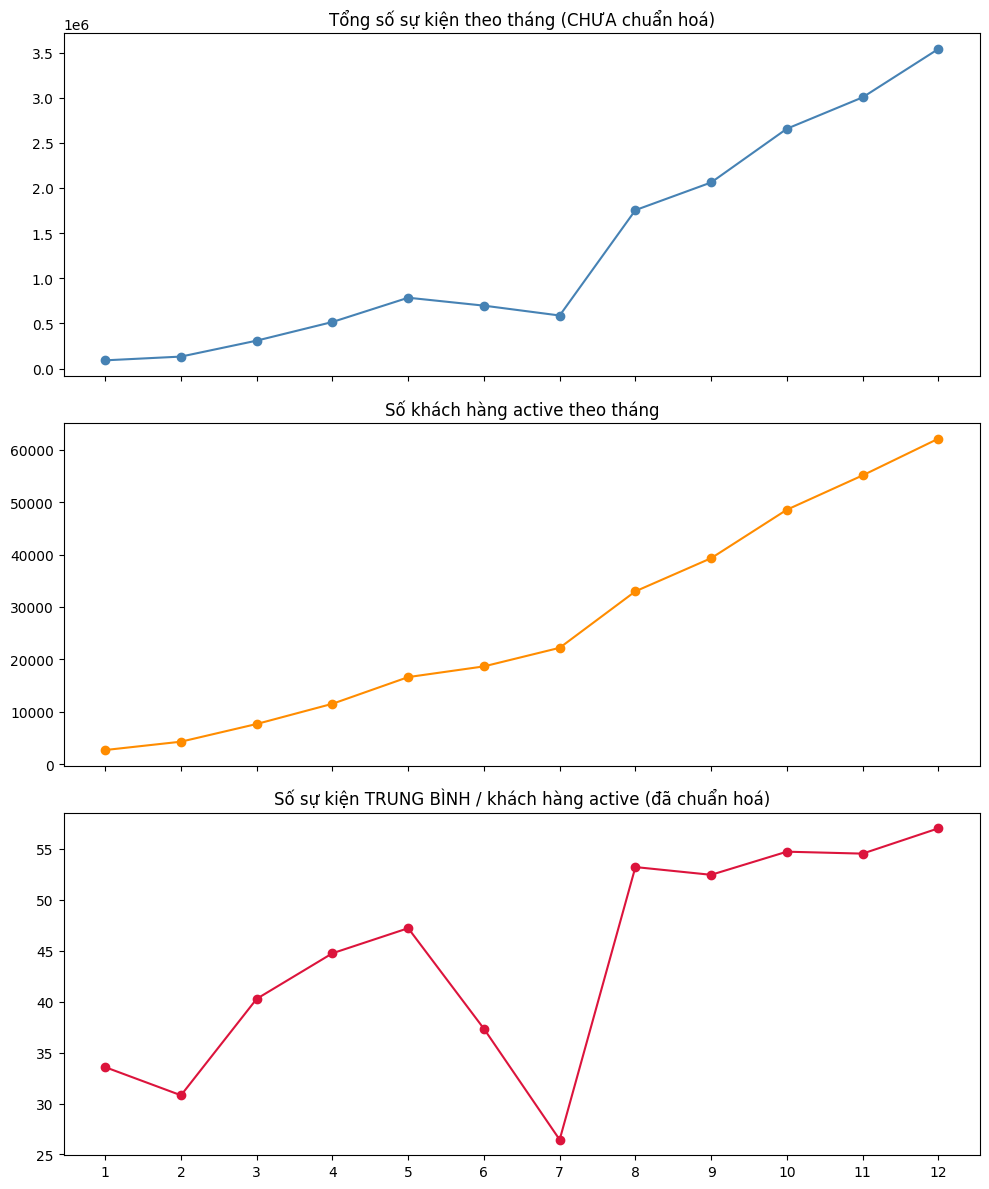

In [90]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
activity["DAY_OF_WEEK"] = pd.Categorical(activity["DAY_OF_WEEK"], categories = weekday_order, ordered = True)
activity["MONTH"] = activity["ACTIVITY_DATE"].dt.month
activity["IS_WEEKEND"] = activity["DAY_OF_WEEK"].isin(["Sat", "Sun"])

# Xu hướng theo tháng, chuẩn hoá theo số khách active
monthly = activity.groupby("MONTH").agg(
    total_events = ("CUSTOMER_NUMBER", "count"),
    active_customers = ("CUSTOMER_NUMBER", "nunique"),
)
monthly["events_per_active_customer"] = (monthly["total_events"] / monthly["active_customers"]).round(2)

fig, axes = plt.subplots(3, 1, figsize = (10, 12), sharex = True)
axes[0].plot(monthly.index, monthly["total_events"], marker = "o", color = "steelblue")
axes[0].set_title("Tổng số sự kiện theo tháng (CHƯA chuẩn hoá)")
axes[1].plot(monthly.index, monthly["active_customers"], marker = "o", color = "darkorange")
axes[1].set_title("Số khách hàng active theo tháng")
axes[2].plot(monthly.index, monthly["events_per_active_customer"], marker = "o", color = "crimson")
axes[2].set_title("Số sự kiện TRUNG BÌNH / khách hàng active (đã chuẩn hoá)")
axes[2].set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

Suplot 1 và 2 đều tăng độ dốc mượt mà từ đầu năm đến cuối năm (Tuy nhiên cả 2 đều hơi "giảm" ở 2 tháng 5-7 nhưng sau đó tăng mạnh trở lại)

Tạm thời giải thích việc tăng mạnh ở thời điểm quý 3 và 4 là do số lượng khách hàng active tăng lên mạnh dẫn đến sự nhảy vọt trong số sự kiện.

Tuy nhiên, sau khi chuẩn hoá ở suplot 3 thì line gãy ở tháng 5 - 7 sau đó lại tăng đột ngột vào tháng 8. Có thể trong tháng 8 ngân hàng có những chương trình ưu đãi hoặc 1 vài vấn đề bất thường khác mà ta chưa lý giải được.

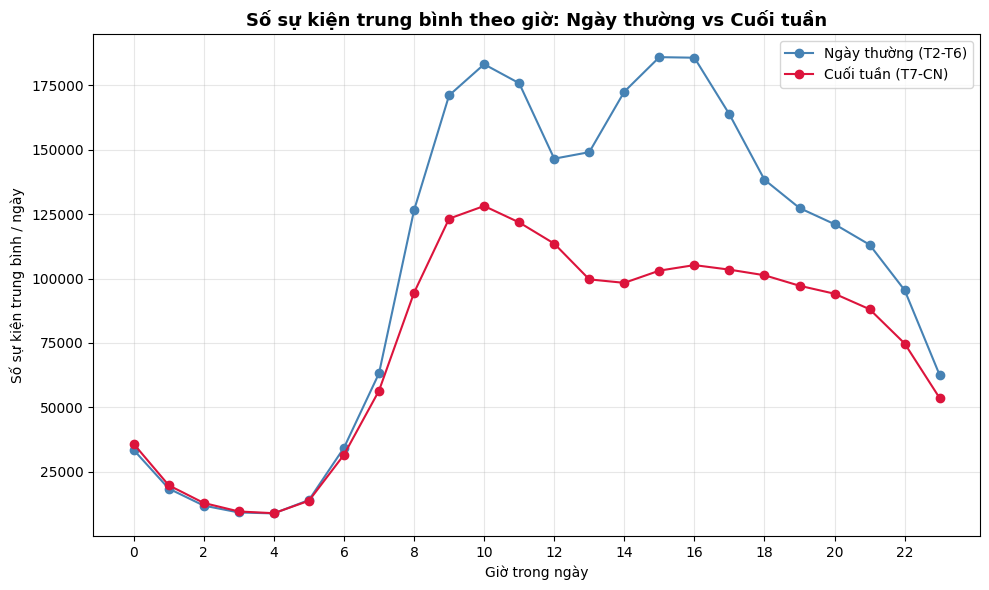

In [91]:
# Giờ hoạt động, tách ngày thường vs cuối tuần
hourly = activity.groupby(["IS_WEEKEND", "ACTIVITY_HOUR"], observed = True).size().unstack(level = 0)
hourly.columns = ["Ngày thường (T2-T6)", "Cuối tuần (T7-CN)"]
hourly["Ngày thường (T2-T6)"] = hourly["Ngày thường (T2-T6)"] / 5   # chuẩn hoá thes số ngày
hourly["Cuối tuần (T7-CN)"] = hourly["Cuối tuần (T7-CN)"] / 2

fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(hourly.index, hourly["Ngày thường (T2-T6)"], marker = "o", label = "Ngày thường (T2-T6)", color = "steelblue")
ax.plot(hourly.index, hourly["Cuối tuần (T7-CN)"], marker = "o", label = "Cuối tuần (T7-CN)", color = "crimson")
ax.set_title("Số sự kiện trung bình theo giờ: Ngày thường vs Cuối tuần", fontsize = 13, weight = "bold")
ax.set_xlabel("Giờ trong ngày"); ax.set_ylabel("Số sự kiện trung bình / ngày")
ax.set_xticks(range(0, 24, 2))
ax.legend(); ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

Có thể thấy hành vi sử dụng/tương tác với ứng dụng chủ yếu tập trung vào sáng sớm (5h -> 7h), giờ hành chính (7h -> 16h) sau đó giảm dần về tối (Hơi suy giảm vào thời gian nghỉ trưa 10 - 12h dẫn đến việc 2 đỉnh)

Pattern rõ ràng và ổn định theo giờ và theo ngày

- Theo giờ: 2 đỉnh rõ rệt lúc 9-11h và 14-16h

- Theo thứ trong tuần: thứ 2-6 hoạt động đều và mạnh, t7 giảm nhẹ và CN giảm rõ ràng nhất.

Pattern không rõ ràng/có bất thường theo tháng

- Phỏng đoán: dấu hiệụ có sự kiện/thay đổi bên ngoài như ra mắt tính năng/chương trình ưu đãi/lỗi hệ thống --> Pattern bị gãy, không mượt như giờ và ngày --> Cần điều tra thêm trước khi dùng làm feature trực tiếp theo tháng.

## 3.2. CUSTOMER NUMBER

In [92]:
per_customer = activity.groupby("CUSTOMER_NUMBER").size()

print("--- Thống kê số dòng log / khách hàng ---")
print(per_customer.describe())

print("\n--- Percentile chi tiết ---")
for p in [10, 25, 50, 75, 90, 95, 99, 99.5, 99.9, 100]:
    print(f"P{p}: {per_customer.quantile(p/100):.0f}")

--- Thống kê số dòng log / khách hàng ---
count    77741.000000
mean       207.518234
std        346.762624
min          1.000000
25%         32.000000
50%         97.000000
75%        241.000000
max       9435.000000
dtype: float64

--- Percentile chi tiết ---
P10: 11
P25: 32
P50: 97
P75: 241
P90: 502
P95: 761
P99: 1610
P99.5: 2133
P99.9: 3812
P100: 9435


In [93]:
Q1, Q3 = per_customer.quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"Ngưỡng outlier IQR (Q3 + 1.5 * IQR): {upper_bound:.0f}")
print(f"Số khách hàng vượt: {(per_customer > upper_bound).sum()} khách hàng "
      f"({(per_customer > upper_bound).mean() * 100:.2f}%)")

Ngưỡng outlier IQR (Q3 + 1.5 * IQR): 554
Số khách hàng vượt: 6701 khách hàng (8.62%)


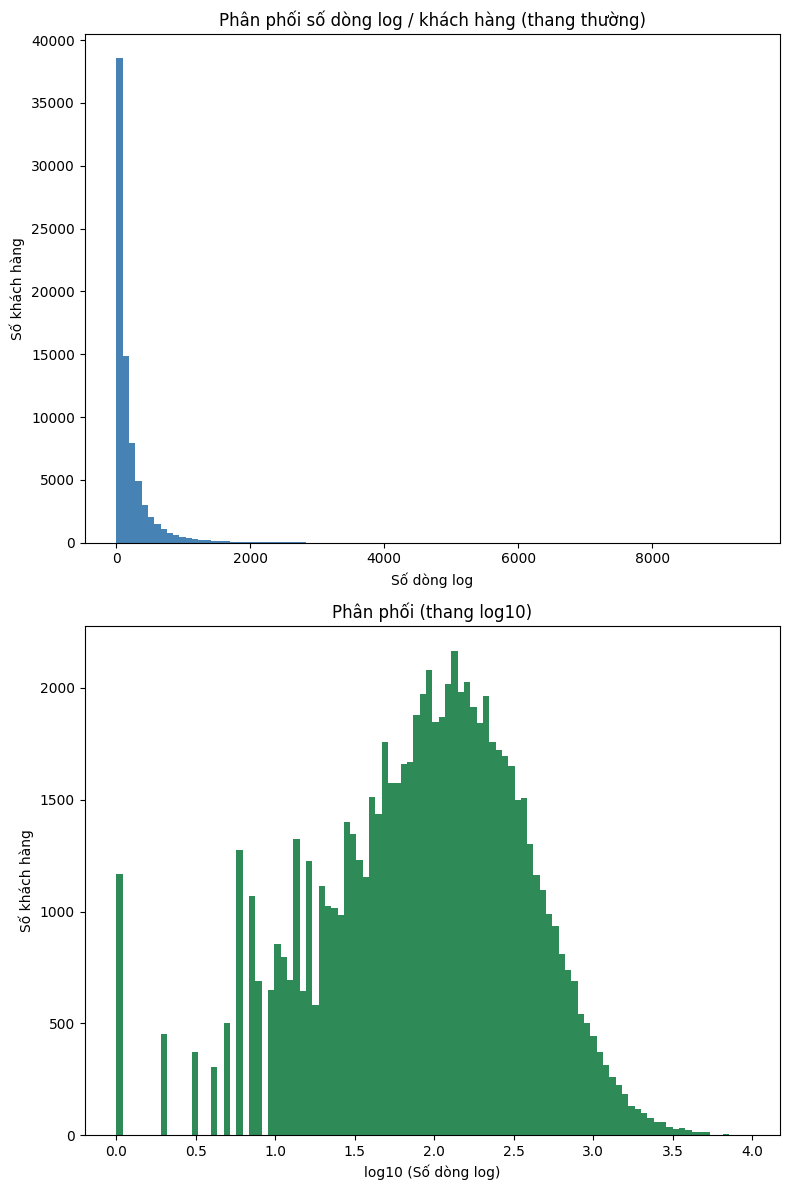

In [94]:
fig, axes = plt.subplots(2, 1, figsize = (8, 12))

axes[0].hist(per_customer, bins = 100, color = "steelblue")
axes[0].set_title("Phân phối số dòng log / khách hàng (thang thường)")
axes[0].set_xlabel("Số dòng log")
axes[0].set_ylabel("Số khách hàng")

axes[1].hist(np.log10(per_customer), bins = 100, color = "seagreen")
axes[1].set_title("Phân phối (thang log10)")
axes[1].set_xlabel("log10 (Số dòng log)")
axes[1].set_ylabel("Số khách hàng")

plt.tight_layout()
plt.show()

Những khách hàng có nhiều dòng log bất thường không phải bot/test app mà là những khách hàng cùng hành vi thật, trải dài trong nhiều ngày cùng hành vi đa dạng --> Không cần loại bỏ những khách hàng này mà có thể gán nhãn IS_POWER_USER

In [95]:
# Top 5 khách hàng nhiều log nhất
top5_ids = per_customer.sort_values(ascending = False).head(5).index

for cid in top5_ids:
    sub = activity[activity["CUSTOMER_NUMBER"] == cid]
    n_days = sub["ACTIVITY_DATE"].nunique()
    n_activities = len(sub)
    top_activity = sub["ACTIVITY_NAME"].value_counts(normalize = True).head(3)

    print(f"--- Customer {cid} ---")
    print(f"Tổng log: {n_activities} | Số ngày active: {n_days} | Trung bình/ngày active: {n_activities / n_days:.1f} ngày")
    print("Top 3 activity phổ biến nhất (tỉ lệ):")
    print(top_activity)
    print()

--- Customer 208370 ---
Tổng log: 9435 | Số ngày active: 215 | Trung bình/ngày active: 43.9 ngày
Top 3 activity phổ biến nhất (tỉ lệ):
ACTIVITY_NAME
LOGIN               0.244091
TRANSFER_VIA_SML    0.242925
LOGOUT              0.238898
Name: proportion, dtype: float64

--- Customer 689022 ---
Tổng log: 8762 | Số ngày active: 318 | Trung bình/ngày active: 27.6 ngày
Top 3 activity phổ biến nhất (tỉ lệ):
ACTIVITY_NAME
LOGIN           0.207030
LOGOUT          0.200639
LOGIN_FACEID    0.160694
Name: proportion, dtype: float64

--- Customer 541251 ---
Tổng log: 7350 | Số ngày active: 248 | Trung bình/ngày active: 29.6 ngày
Top 3 activity phổ biến nhất (tỉ lệ):
ACTIVITY_NAME
LOGIN                    0.196327
LOGOUT                   0.188707
MB_INTEREST_RATE_VIEW    0.151973
Name: proportion, dtype: float64

--- Customer 980868 ---
Tổng log: 7016 | Số ngày active: 172 | Trung bình/ngày active: 40.8 ngày
Top 3 activity phổ biến nhất (tỉ lệ):
ACTIVITY_NAME
LOGIN                    0.163056
LOGO

In [96]:
p95_threshold = per_customer.quantile(0.95)

customer_activity_summary = per_customer.reset_index()
customer_activity_summary.columns = ["CUSTOMER_NUMBER", "TOTAL_ACTIVITY_COUNT"]
customer_activity_summary["IS_POWER_USER"] = (
    customer_activity_summary["TOTAL_ACTIVITY_COUNT"] > p95_threshold
).astype(int)

print(f"\nNgưỡng Power User (P95): {p95_threshold:.0f}")
print(customer_activity_summary["IS_POWER_USER"].value_counts())


Ngưỡng Power User (P95): 761
IS_POWER_USER
0    73856
1     3885
Name: count, dtype: int64


## 3.3. KIỂM TRA TÍNH NHẤT QUÁN THỜI GIAN

In [97]:
first_activity = activity.groupby("CUSTOMER_NUMBER")["ACTIVITY_DATE"].min().reset_index()
first_activity.columns = ["CUSTOMER_NUMBER", "FIRST_ACTIVITY_DATE"]


customer = pd.read_csv("customer_clean.csv")
check = first_activity.merge(
    customer[["CUSTOMER_NUMBER", "CLIENT_CREATE_DATE", "IB_REGISTER_DATE"]],
    on = "CUSTOMER_NUMBER", how = "left"
)

# 1. Khách hàng có Activity nhưng không tồn tại trong Customer (khách hàng "ma")
print("Khách hàng 'ma':", check["CLIENT_CREATE_DATE"].isna().sum())

# 2. Hoạt động xảy ra TRƯỚC ngày mở tài khoản (vô lý về logic)
before_create = check["FIRST_ACTIVITY_DATE"] < check["CLIENT_CREATE_DATE"]
print("Hoạt động trước ngày mở tài khoản:", before_create.sum())

# 3. Hoạt động xảy ra TRƯỚC ngày đăng ký IB (vô lý, vì Activity = log trên IB)
before_ib = check["FIRST_ACTIVITY_DATE"] < check["IB_REGISTER_DATE"]
print("Hoạt động trước ngày đăng ký IB:", before_ib.sum())

# 4. Có Activity nhưng Customer lại ghi nhận "chưa đăng ký IB" (mâu thuẫn trực tiếp)
no_ib_but_active = check["IB_REGISTER_DATE"].isna()
print("Có activity nhưng Customer nói chưa đăng ký IB:", no_ib_but_active.sum())


Khách hàng 'ma': 0
Hoạt động trước ngày mở tài khoản: 906
Hoạt động trước ngày đăng ký IB: 1527
Có activity nhưng Customer nói chưa đăng ký IB: 1


/var/folders/b1/491xk5n932bfp5bf2vg1cfw40000gn/T/ipykernel_22027/2591181722.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  customer = pd.read_csv("customer_clean.csv")


**Nhận xét:** Kiểm tra tính nhất quán thời gian giữa Activity và Customer

**Đối chiếu ngày hoạt động đầu tiên (`FIRST_ACTIVITY_DATE`) với `CLIENT_CREATE_DATE` và `IB_REGISTER_DATE`:**

- **Không có khách hàng "ma"**: toàn bộ 77.741 khách hàng trong Activity đều tồn tại trong bảng Customer — dữ liệu join sạch, không cần lo dữ liệu bị lẫn nguồn khác.

- **906 khách hàng có hoạt động trước ngày mở tài khoản**, **1.527 khách hàng có hoạt động trước ngày đăng ký IB** (~1.2–2% tổng số). Đáng chú ý: độ lệch **không nhỏ** như kỳ vọng ban đầu (lỗi timezone/làm tròn) — trung vị lệch tới **53 ngày**, trung bình **106 ngày**, tối đa **764 ngày**. Chỉ ~12% nhóm này lệch đúng 1 ngày (nhiều khả năng mới là lỗi kỹ thuật thật).

- **Kết luận**: cột `IB_REGISTER_DATE` ở bảng Customer **có thể không đáng tin cậy hoàn toàn** để dùng làm mốc "thời điểm bắt đầu dùng dịch vụ" — nhiều khả năng nó phản ánh **lần đăng ký gần nhất** (re-registration, đổi máy/cài lại app) chứ không phải lần đăng ký đầu tiên, khiến ngày bị trễ hơn hoạt động thực tế đã ghi nhận từ trước. Log Activity (event-level, chi tiết hơn) được xem là đáng tin hơn trong trường hợp mâu thuẫn.

- **1 khách hàng có Activity nhưng Customer báo "chưa đăng ký IB"** (`CUSTOMER_NUMBER = 902983`) — kiểm tra chi tiết cho thấy đây chỉ là 1 sự kiện LOGIN đơn lẻ, duy nhất trong cả năm. Do tần suất quá hiếm (1/77.741), xem đây là edge-case cá biệt, không phải lỗi hệ thống, không cần xử lý đặc biệt.

**Hướng xử lý:** Không chỉnh sửa dữ liệu Activity dựa trên độ lệch này. Thay vào đó, gắn flag `IB_REGISTER_DATE_INCONSISTENT` cho nhóm 1.527 khách hàng bị lệch, để lưu ý khi dùng `IB_REGISTER_DATE` làm feature tenure (thời gian sử dụng dịch vụ) ở bước sau — tránh tính sai "độ mới/cũ" của khách hàng dựa trên mốc thời gian không đáng tin cậy này.

In [98]:
# Tạo flag IB_REGISTER_DATE_INCONSISTENT
# = 1 nếu: hoạt động đầu tiên xảy ra TRƯỚC ngày đăng ký IB
#          HOẶC có activity nhưng Customer báo chưa từng đăng ký IB
# => Đánh dấu nhóm khách hàng mà IB_REGISTER_DATE không đáng tin cậy
#    để dùng làm mốc "thời điểm bắt đầu dùng dịch vụ" (tenure)

first_activity = activity.groupby("CUSTOMER_NUMBER")["ACTIVITY_DATE"].min().reset_index()
first_activity.columns = ["CUSTOMER_NUMBER", "FIRST_ACTIVITY_DATE"]

check = first_activity.merge(
    customer[["CUSTOMER_NUMBER", "CLIENT_CREATE_DATE", "IB_REGISTER_DATE"]],
    on = "CUSTOMER_NUMBER", how = "left"
)

check["IB_REGISTER_DATE_INCONSISTENT"] = (
    (check["FIRST_ACTIVITY_DATE"] < check["IB_REGISTER_DATE"])
    | (check["IB_REGISTER_DATE"].isna())
).astype(int)

print(check["IB_REGISTER_DATE_INCONSISTENT"].value_counts())

# Gộp flag này vào bảng summary theo khách hàng (customer_activity_summary đã tạo ở bước trước)
customer_activity_summary = customer_activity_summary.merge(
    check[["CUSTOMER_NUMBER", "FIRST_ACTIVITY_DATE", "IB_REGISTER_DATE_INCONSISTENT"]],
    on = "CUSTOMER_NUMBER", how = "left"
)

IB_REGISTER_DATE_INCONSISTENT
0    76213
1     1528
Name: count, dtype: int64


In [99]:
# Phân loại ACTIVITY_STATUS cho TOÀN BỘ khách hàng trong Customer
# (không chỉ 77.741 khách có log, mà cả những khách "vắng mặt" trong Activity)
# => Phân biệt rõ 4 lý do khác nhau dẫn đến việc "không có activity log"

active_customer_ids = set(activity["CUSTOMER_NUMBER"].unique())

def classify_activity_status(row):
    if row["CUSTOMER_NUMBER"] in active_customer_ids:
        return "ACTIVE"                          # Có ít nhất 1 dòng log
    if pd.isna(row["IB_REGISTER_DATE"]):
        return "NOT_REGISTERED"                   # Chưa từng đăng ký IB
    if row["IB_REGISTER_DATE"].year != 2019:
        return "REGISTERED_OUTSIDE_COVERAGE"       # Đăng ký 2020-2021, ngoài phạm vi data Activity (chỉ có 2019)
    return "REGISTERED_NO_ACTIVITY"                # Đăng ký trong 2019 nhưng chưa từng dùng

customer["IB_REGISTER_DATE"] = pd.to_datetime(customer["IB_REGISTER_DATE"], errors = "coerce") # Chuyển kiểu dữ liệu của IB_REGISTER_DATE trong customer sang datetime

customer["ACTIVITY_STATUS"] = customer.apply(classify_activity_status, axis = 1)
print(customer["ACTIVITY_STATUS"].value_counts())

# Gộp vào bảng summary Activity để tiện merge chính thức ở Giai đoạn 5
customer_activity_summary = customer_activity_summary.merge(
    customer[["CUSTOMER_NUMBER", "ACTIVITY_STATUS"]],
    on = "CUSTOMER_NUMBER", how = "right"
)

ACTIVITY_STATUS
NOT_REGISTERED                 131247
ACTIVE                          77741
REGISTERED_NO_ACTIVITY          56766
REGISTERED_OUTSIDE_COVERAGE     24469
Name: count, dtype: int64


**Nhận xét:** Vì sao 51.1% khách đã đăng ký IB lại không có Activity log?

Đối chiếu ngược lại — trong số 158.975 khách hàng đã đăng ký IB (theo bảng Customer), có tới **81.235 người (51.1%)** không để lại bất kỳ dòng log nào trong Activity. Con số này lớn, nhưng khi phân tách nguyên nhân thì hoá ra đến từ 2 lý do rất khác nhau:

- **~30% (24.469 người)** đăng ký IB vào năm **2020-2021**, trong khi dữ liệu Activity **chỉ ghi nhận năm 2019**. Nhóm này không thể có log không phải vì họ không dùng, mà đơn giản vì **dữ liệu Activity không phủ tới thời điểm đó** — đây là giới hạn phạm vi (coverage) của dataset, không phải bất thường hành vi.

- **~70% còn lại (56.766 người)** đăng ký ngay trong năm 2019 — tức có đủ thời gian để phát sinh hoạt động — nhưng vẫn **0 log suốt cả năm**. Tính riêng trên nhóm đăng ký trong 2019, tỷ lệ này lên tới **42.3%**. Đây nhiều khả năng là hiện tượng **"đăng ký nhưng không dùng"** khá phổ biến trong ngân hàng số — đặc biệt khi phần lớn khách đăng ký qua kênh `BRANCH` (được nhân viên hỗ trợ đăng ký hộ tại quầy) chứ không tự đăng ký trên app, nên nhiều người có tài khoản IB nhưng chưa từng chủ động mở ra dùng.

**Vì sao phát hiện này quan trọng:** nó cho thấy `HAS_IB_ACCOUNT` (đã đăng ký hay chưa) và "mức độ tương tác số thực tế" là **2 khái niệm hoàn toàn khác nhau**, không nên gộp chung thành 1 feature. Khách "đăng ký nhưng không dùng" nhiều khả năng có hành vi/propensity khác hẳn khách dùng app thường xuyên — nên tách riêng bằng cột `ACTIVITY_STATUS` (4 nhóm: `ACTIVE`, `NOT_REGISTERED`, `REGISTERED_NO_ACTIVITY`, `REGISTERED_OUTSIDE_COVERAGE`) để giữ lại đầy đủ thông tin này cho bước modeling sau.

In [100]:
# Định nghĩa từ điển mapping

activity_mapping = {
    # Nhóm Đăng nhập & Bảo mật
    "LOGIN": "AUTH_SECURITY", "LOGOUT": "AUTH_SECURITY", "LOGIN_FINGER": "AUTH_SECURITY",
    "LOGIN_FACEID": "AUTH_SECURITY", "AUTHENTICATION": "AUTH_SECURITY", "CHANGE_PASSWORD": "AUTH_SECURITY",
    "MB_SET_PIN": "AUTH_SECURITY", "MB_CHANGE_PIN": "AUTH_SECURITY", "MB_RESET_PIN": "AUTH_SECURITY",
    "SET_PASSWORD": "AUTH_SECURITY",

    # Nhóm Chuyển khoản
    "TRANSFER_VIA_SML": "TRANSFER", "TRANSFER_BANK_ACCOUNT": "TRANSFER",
    "TRANSFER_VIA_PAYMENT_CENTER": "TRANSFER", "TRANSFER_VIA_SML_ACCOUNT": "TRANSFER",
    "TRANSFER_INTERNATIONAL": "TRANSFER", "TRANSFER_BANK_ACCOUNT_BULK": "TRANSFER",
    "TRANSFER_VIA_PHONENO": "TRANSFER",

    # Nhóm Thanh toán hóa đơn & Nạp tiền
    "TOPUP_MOBILE": "PAYMENT", "MB_BILLPAY": "PAYMENT", "RB_BILLPAY_WATER": "PAYMENT",
    "RB_BILLPAY_ADSL": "PAYMENT", "RB_BILLPAY_INSURANCE": "PAYMENT", "RB_BILLPAY_MOBILE": "PAYMENT",
    "RB_BILLPAY_HOMEPHONE": "PAYMENT", "RB_BILLPAY_TELECOMMUNICATIONS": "PAYMENT", "RB_BILLPAY_PSTN": "PAYMENT",

    # Nhóm Tra cứu & Quản lý
    "QUERY_ACCOUNT_INFORMATION": "INQUIRY", "TRANSACTION_OVERVIEW_QUERY": "INQUIRY",
    "TRANSACTION_DETAIL_QUERY": "INQUIRY", "QUERY_CURRENT_ACCOUNT": "INQUIRY",
    "QUERY_ACCOUNT_PORFOLIO": "INQUIRY", "QUERY_MM_ACCOUNT": "INQUIRY", "MB_ACCOUNT_QUICK_BALANCE": "INQUIRY",

    # Nhóm Quan tâm Tín dụng/Vay
    "QUERY_LOAN_ACCOUNT": "CREDIT_LOAN", "EXPORT_ACCOUNT_STATEMENT_LOAN": "CREDIT_LOAN",
    "CARD_EGIFT_REGISTER_CASHBACK": "CREDIT_LOAN", "CARD_EGIFT_REGISTER_REDEEM": "CREDIT_LOAN",
    "CARD_EGIFT_REGISTER_ANNUALFEE": "CREDIT_LOAN",

    # Nhóm Quan tâm Đầu tư/Tiết kiệm
    "MB_INTEREST_RATE_VIEW": "INVEST_SAVING", "MB_EXCHANGE_RATE_VIEW": "INVEST_SAVING",

    # Nhóm Tiện ích
    "MB_LOCATION_POS_VIEW": "UTILITY", "MB_LOCATION_BRANCH_VIEW": "UTILITY",
    "MB_LOCATION_ATM_VIEW": "UTILITY", "ACCOUNT_ADDRESS_BOOK_UPDATE": "UTILITY",
    "ACCOUNT_ADDRESS_BOOK_DELETE": "UTILITY"
}

# Map dữ liệu
activity["ACTIVITY_GROUP"] = activity["ACTIVITY_NAME"].map(activity_mapping)

# Kiểm tra có activity nào bị sót (NaN) do gõ sai tên không
unmapped_activities = activity[activity["ACTIVITY_GROUP"].isna()]["ACTIVITY_NAME"].unique()
print("Các hoạt động chưa được map:", unmapped_activities)

Các hoạt động chưa được map: []


## 3.4. Feature Engineering

In [101]:
observation_cutoff = pd.Timestamp("2019-10-01")   # Quý 1-Quý 3 dùng để tính feature
prediction_end = pd.Timestamp("2020-01-01")       # Quý 4 dùng để tạo label (áp dụng khi xử lý Deposit/Card/Lend sau này)

activity_obs = activity[activity["ACTIVITY_DATE"] < observation_cutoff].copy()

print("Số dòng trước cutoff (dùng cho feature):", len(activity_obs))
print("Số khách hàng active trong observation window:", activity_obs["CUSTOMER_NUMBER"].nunique())

Số dòng trước cutoff (dùng cho feature): 6931326
Số khách hàng active trong observation window: 47589


In [102]:
observation_cutoff = pd.Timestamp("2019-10-01")
activity_obs = activity[activity["ACTIVITY_DATE"] < observation_cutoff].copy()

# NHÓM 1: FEATURE KHỐI LƯỢNG TƯƠNG TÁC (volume)
feat_volume = activity_obs.groupby("CUSTOMER_NUMBER").agg(
    TOTAL_ACTIVITY_COUNT = ("ACTIVITY_NAME", "count"),
    ACTIVE_DAYS = ("ACTIVITY_DATE", "nunique"),
    FIRST_ACTIVITY_DATE = ("ACTIVITY_DATE", "min"),
    LAST_ACTIVITY_DATE = ("ACTIVITY_DATE", "max"),
).reset_index()

# Mật độ: số hoạt động trung bình / ngày active (không phải tổng thô)
feat_volume["ACTIVITY_PER_ACTIVE_DAY"] = (
    feat_volume["TOTAL_ACTIVITY_COUNT"] / feat_volume["ACTIVE_DAYS"]
).round(2)

# Khoảng thời gian trải dài từ lần hoạt động đầu đến cuối (trong observation window)
feat_volume["ACTIVITY_SPAN_DAYS"] = (
    feat_volume["LAST_ACTIVITY_DATE"] - feat_volume["FIRST_ACTIVITY_DATE"]
).dt.days

# Mức độ đều đặn: tỷ lệ ngày active / tổng số ngày trải dài
# (+1 để tránh chia 0 khi span=0, tức chỉ hoạt động đúng 1 ngày duy nhất)
feat_volume["ACTIVE_DAY_RATIO"] = (
    feat_volume["ACTIVE_DAYS"] / (feat_volume["ACTIVITY_SPAN_DAYS"] + 1)
).round(3)

feat_volume.describe()

,CUSTOMER_NUMBER,TOTAL_ACTIVITY_COUNT,ACTIVE_DAYS,FIRST_ACTIVITY_DATE,LAST_ACTIVITY_DATE,ACTIVITY_PER_ACTIVE_DAY,ACTIVITY_SPAN_DAYS,ACTIVE_DAY_RATIO
count,47589.000000,47589.000000,47589.000000,47589,47589,47589.000000,47589.000000,47589.000000
mean,501387.329236,145.649751,20.162958,2019-06-17 20:08:23.813906432,2019-09-08 18:47:50.831494656,6.544843,82.944063,0.364653
min,0.000000,1.000000,1.000000,2019-01-01 00:00:00,2019-01-02 00:00:00,1.000000,0.000000,0.008000
25%,250344.000000,24.000000,4.000000,2019-04-22 00:00:00,2019-09-13 00:00:00,5.000000,19.000000,0.148000
50%,503522.000000,70.000000,12.000000,2019-07-19 00:00:00,2019-09-25 00:00:00,6.000000,62.000000,0.267000
75%,751065.000000,173.000000,28.000000,2019-08-20 00:00:00,2019-09-29 00:00:00,7.480000,137.000000,0.479000
max,999982.000000,5701.000000,226.000000,2019-09-30 00:00:00,2019-09-30 00:00:00,64.410000,271.000000,1.000000
std,288914.287923,233.293221,23.560541,NaN,NaN,2.836125,73.195606,0.293117


In [103]:
# NHÓM 2: FEATURE ĐA DẠNG HÀNH VI (diversity)
activity_obs["ACTIVITY_GROUP"] = activity_obs["ACTIVITY_NAME"].map(activity_mapping)

feat_diversity = activity_obs.groupby("CUSTOMER_NUMBER").agg(
    N_DISTINCT_ACTIVITY_NAME = ("ACTIVITY_NAME", "nunique"),
    N_DISTINCT_ACTIVITY_GROUP = ("ACTIVITY_GROUP", "nunique"),
).reset_index()

# Chỉ số đa dạng Shannon entropy - đo mức độ "dàn trải" hành vi
# (không chỉ đếm SỐ LOẠI, mà còn xét TỶ TRỌNG mỗi loại có cân bằng không)
def shannon_entropy(group):
    counts = group.value_counts(normalize = True)
    return -(counts * np.log2(counts)).sum()

entropy_by_customer = activity_obs.groupby("CUSTOMER_NUMBER")["ACTIVITY_GROUP"].apply(shannon_entropy)
feat_diversity = feat_diversity.merge(
    entropy_by_customer.rename("ACTIVITY_GROUP_ENTROPY").reset_index(),
    on="CUSTOMER_NUMBER"
)

feat_diversity.describe()

,CUSTOMER_NUMBER,N_DISTINCT_ACTIVITY_NAME,N_DISTINCT_ACTIVITY_GROUP,ACTIVITY_GROUP_ENTROPY
count,47589.000000,47589.000000,47589.000000,47589.000000
mean,501387.329236,9.481771,4.318036,1.555322
std,288914.287923,3.186511,1.276065,0.389457
min,0.000000,1.000000,1.000000,-0.000000
25%,250344.000000,7.000000,3.000000,1.431006
50%,503522.000000,9.000000,4.000000,1.623083
75%,751065.000000,12.000000,5.000000,1.788398
max,999982.000000,25.000000,7.000000,2.385213


In [104]:
# NHÓM 3: FEATURE THEO NHÓM SẢN PHẨM/NGHIỆP VỤ
# Đếm số lượng activity theo từng nhóm, mỗi khách hàng 1 dòng
group_counts = activity_obs.groupby(["CUSTOMER_NUMBER", "ACTIVITY_GROUP"]).size().unstack(fill_value = 0)
group_counts.columns = [f"CNT_{c}" for c in group_counts.columns]

# Tỷ trọng (%) mỗi nhóm trên tổng activity của khách hàng đó
group_props = group_counts.div(group_counts.sum(axis = 1), axis = 0)
group_props.columns = [c.replace("CNT_", "PCT_") for c in group_counts.columns]

feat_group = pd.concat([group_counts, group_props], axis = 1).reset_index()

# Feature nhị phân: khách hàng có TỪNG chạm nhóm hiếm-nhưng-đắt-giá không (CREDIT_LOAN)
feat_group["HAS_CREDIT_LOAN_SIGNAL"] = (feat_group["CNT_CREDIT_LOAN"] > 0).astype(int)

feat_group.head()

,CUSTOMER_NUMBER,CNT_AUTH_SECURITY,CNT_CREDIT_LOAN,CNT_INQUIRY,CNT_INVEST_SAVING,CNT_PAYMENT,CNT_TRANSFER,CNT_UTILITY,PCT_AUTH_SECURITY,PCT_CREDIT_LOAN,PCT_INQUIRY,PCT_INVEST_SAVING,PCT_PAYMENT,PCT_TRANSFER,PCT_UTILITY,HAS_CREDIT_LOAN_SIGNAL
0,0,4,0,1,1,0,1,0,0.571429,0.0,0.142857,0.142857,0.0,0.142857,0.000000,0
1,3,24,0,11,8,0,0,4,0.510638,0.0,0.234043,0.170213,0.0,0.000000,0.085106,0
2,13,8,0,3,2,0,0,0,0.615385,0.0,0.230769,0.153846,0.0,0.000000,0.000000,0
3,32,71,0,39,17,0,3,0,0.546154,0.0,0.300000,0.130769,0.0,0.023077,0.000000,0
4,44,48,0,9,14,0,3,1,0.640000,0.0,0.120000,0.186667,0.0,0.040000,0.013333,0


In [105]:
# NHÓM 4: FEATURE XU HƯỚNG (TREND) - nửa đầu vs nửa sau observation window
observation_start = pd.Timestamp("2019-01-01")
midpoint = observation_start + (observation_cutoff - observation_start) / 2

activity_obs["HALF"] = np.where(activity_obs["ACTIVITY_DATE"] < midpoint, "FIRST_HALF", "SECOND_HALF")

half_counts = activity_obs.groupby(["CUSTOMER_NUMBER", "HALF"]).size().unstack(fill_value=0)
half_counts.columns = [f"ACTIVITY_CNT_{c}" for c in half_counts.columns]

# QUAN TRỌNG: chỉ tính TREND_RATIO cho khách có hoạt động ở CẢ 2 nửa
# (tránh nhầm "mới bắt đầu dùng ở nửa sau" với "tăng trưởng tương tác thật")
has_both_halves = (half_counts["ACTIVITY_CNT_FIRST_HALF"] > 0) & (half_counts["ACTIVITY_CNT_SECOND_HALF"] > 0)

half_counts["TREND_RATIO"] = np.nan
half_counts.loc[has_both_halves, "TREND_RATIO"] = (
    half_counts.loc[has_both_halves, "ACTIVITY_CNT_SECOND_HALF"]
    / half_counts.loc[has_both_halves, "ACTIVITY_CNT_FIRST_HALF"]
).round(3)

# Khách chỉ xuất hiện ở nửa sau -> gắn nhãn riêng, không gán ratio giả tạo
half_counts["NEW_IN_SECOND_HALF"] = (
    (half_counts["ACTIVITY_CNT_FIRST_HALF"] == 0) & (half_counts["ACTIVITY_CNT_SECOND_HALF"] > 0)
).astype(int)

feat_trend = half_counts.reset_index()
feat_trend.describe()

,CUSTOMER_NUMBER,ACTIVITY_CNT_FIRST_HALF,ACTIVITY_CNT_SECOND_HALF,TREND_RATIO,NEW_IN_SECOND_HALF
count,47589.000000,47589.000000,47589.000000,14487.000000,47589.000000
mean,501387.329236,30.510853,115.138898,5.199883,0.654164
std,288914.287923,86.863414,181.739158,18.981656,0.475645
min,0.000000,0.000000,0.000000,0.001000,0.000000
25%,250344.000000,0.000000,19.000000,0.769500,0.000000
50%,503522.000000,0.000000,57.000000,1.675000,1.000000
75%,751065.000000,20.000000,139.000000,3.905000,1.000000
max,999982.000000,2544.000000,4354.000000,1011.000000,1.000000


In [106]:
# NHÓM 5: FEATURE PATTERN THỜI GIAN
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
activity_obs["DAY_OF_WEEK"] = pd.Categorical(activity_obs["DAY_OF_WEEK"], categories = weekday_order, ordered = True)
activity_obs["IS_WEEKEND"] = activity_obs["DAY_OF_WEEK"].isin(["Sat", "Sun"])
activity_obs["IS_BUSINESS_HOUR"] = activity_obs["ACTIVITY_HOUR"].between(8, 17)

feat_time = activity_obs.groupby("CUSTOMER_NUMBER").agg(
    MOST_COMMON_HOUR=("ACTIVITY_HOUR", lambda x: x.mode().iloc[0]),
    WEEKEND_ACTIVITY_RATIO=("IS_WEEKEND", "mean"),
    BUSINESS_HOUR_RATIO=("IS_BUSINESS_HOUR", "mean"),
).reset_index()

feat_time["WEEKEND_ACTIVITY_RATIO"] = feat_time["WEEKEND_ACTIVITY_RATIO"].round(3)
feat_time["BUSINESS_HOUR_RATIO"] = feat_time["BUSINESS_HOUR_RATIO"].round(3)

feat_time.describe()

,CUSTOMER_NUMBER,MOST_COMMON_HOUR,WEEKEND_ACTIVITY_RATIO,BUSINESS_HOUR_RATIO
count,47589.000000,47589.000000,47589.000000,47589.000000
mean,501387.329236,13.427935,0.200568,0.693867
std,288914.287923,4.279706,0.182689,0.217201
min,0.000000,0.000000,0.000000,0.000000
25%,250344.000000,10.000000,0.068000,0.576000
50%,503522.000000,13.000000,0.188000,0.700000
75%,751065.000000,16.000000,0.276000,0.839000
max,999982.000000,23.000000,1.000000,1.000000


In [107]:
# Gộp cả 5 nhóm thành 1 bảng feature Activity
activity_feature_table = (
    feat_volume
    .merge(feat_diversity, on = "CUSTOMER_NUMBER", how = "outer")
    .merge(feat_group, on = "CUSTOMER_NUMBER", how = "outer")
    .merge(feat_trend, on = "CUSTOMER_NUMBER", how = "outer")
    .merge(feat_time, on = "CUSTOMER_NUMBER", how = "outer")
)

print(activity_feature_table.shape)
activity_feature_table.head()

(47589, 33)


,CUSTOMER_NUMBER,TOTAL_ACTIVITY_COUNT,ACTIVE_DAYS,FIRST_ACTIVITY_DATE,LAST_ACTIVITY_DATE,ACTIVITY_PER_ACTIVE_DAY,ACTIVITY_SPAN_DAYS,ACTIVE_DAY_RATIO,N_DISTINCT_ACTIVITY_NAME,N_DISTINCT_ACTIVITY_GROUP,...,PCT_TRANSFER,PCT_UTILITY,HAS_CREDIT_LOAN_SIGNAL,ACTIVITY_CNT_FIRST_HALF,ACTIVITY_CNT_SECOND_HALF,TREND_RATIO,NEW_IN_SECOND_HALF,MOST_COMMON_HOUR,WEEKEND_ACTIVITY_RATIO,BUSINESS_HOUR_RATIO
0,0,7,1,2019-09-26,2019-09-26,7.00,0,1.000,7,4,...,0.142857,0.000000,0,0,7,NaN,1,9,0.000,1.000
1,3,47,9,2019-06-05,2019-09-29,5.22,116,0.077,7,4,...,0.000000,0.085106,0,0,47,NaN,1,15,0.362,0.489
2,13,13,2,2019-09-06,2019-09-07,6.50,1,1.000,7,3,...,0.000000,0.000000,0,0,13,NaN,1,15,0.308,0.692
3,32,130,21,2019-07-19,2019-09-30,6.19,73,0.284,11,4,...,0.023077,0.000000,0,0,130,NaN,1,17,0.200,0.608
4,44,75,13,2019-04-04,2019-09-19,5.77,168,0.077,10,5,...,0.040000,0.013333,0,38,37,0.974,0,12,0.000,0.667


In [108]:
activity_feature_table.to_csv("activity_clean.csv", index = False)
print(f"Đã lưu: activity_clean.csv | Shape: {activity_feature_table.shape}")

Đã lưu: activity_clean.csv | Shape: (47589, 33)
